# Spotify Decoded — Exploratory Data Analysis

I requested my full Spotify streaming history, every play, skip, and timestamp since I first opened the app. What came back were 9 JSON files spanning October 2020 to April 2026: **80,512 plays, 2,729 hours, 1,750 artists.**

This notebook is the first pass through that data. No models yet, just careful observation. The goal is to understand the shape of the data before making any claims about it, and to surface the patterns that are worth investigating further.

*Technical note: all timestamps are converted to IST (Asia/Kolkata) for 2020–2023 and local time for subsequent years, reflecting where the listening actually happened.*


In [2]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Load data ──────────────────────────────────────────────────────────────
from spotify_parser import load_all, summary

df_tracks, df_podcasts = load_all("../data/raw/")
summary(df_tracks)


Loaded 80,623 raw records from 9 files
  → 80,512 music tracks
  → 111 podcast plays
  → Date range: 2020-10-31 → 2026-04-02
  → Total listening: 2728.7 hours
SPOTIFY LISTENING SUMMARY
Total plays         : 80,512
Unique artists      : 1,750
Unique tracks       : 7,039
Total hours         : 2,728.7 h
Date range          : 2020-10-31 → 2026-04-02
Top artist          : NCT DREAM
Most played track   : Teddy Bear
Skip rate           : 31.0%
Countries           : ['India', 'United Kingdom', 'United States']
Platforms           : ['Android', 'Other', 'Windows', 'macOS']


Colour palette and defaults

In [3]:
# Consistent palette used throughout the project
PALETTE = {
    "primary":   "#1DB954",   # Spotify green
    "secondary": "#191414",   # Spotify black
    "accent":    "#FF6B6B",   # warm red for highlights
    "muted":     "#B3B3B3",   # grey for background bars
    "india":     "#FF9933",   # saffron
    "us":        "#3C8DBC",   # blue
}

YEARS_PALETTE = {
    2020: "#E8F5E9", 2021: "#A5D6A7", 2022: "#4CAF50",
    2023: "#2E7D32", 2024: "#81C784", 2025: "#1DB954", 2026: "#66BB6A"
}

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.family":       "sans-serif",
    "figure.dpi":        150,
})

print("Palette and defaults loaded.")


Palette and defaults loaded.


Headline numbers

Before any visualisation, it helps to anchor the analysis with a few summary figures. These numbers set the scale, they tell us whether we're working with a casual listener's data or something more substantial.


In [4]:
total_hours   = df_tracks["ms_played"].sum() / 3_600_000
total_days    = total_hours / 24
unique_artists = df_tracks["artist_name"].nunique()
unique_tracks  = df_tracks["track_name"].nunique()
date_range    = (df_tracks["ts"].max() - df_tracks["ts"].min()).days
skip_rate     = df_tracks["skipped"].mean() * 100
top_artist    = df_tracks["artist_name"].value_counts().index[0]
top_track     = df_tracks["track_name"].value_counts().index[0]
top_track_plays = df_tracks["track_name"].value_counts().iloc[0]

stats = {
    "Total plays":        f"{len(df_tracks):,}",
    "Total hours":        f"{total_hours:,.0f} h  ({total_days:.0f} days)",
    "Unique artists":     f"{unique_artists:,}",
    "Unique tracks":      f"{unique_tracks:,}",
    "Span":               f"{date_range} days (Oct 2020 – Apr 2026)",
    "Skip rate":          f"{skip_rate:.1f}%",
    "Top artist":         top_artist,
    "Most played track":  f"{top_track}  ({top_track_plays:,} plays)",
}

for k, v in stats.items():
    print(f"  {k:<22} {v}")


  Total plays            80,512
  Total hours            2,729 h  (114 days)
  Unique artists         1,750
  Unique tracks          7,039
  Span                   1979 days (Oct 2020 – Apr 2026)
  Skip rate              31.0%
  Top artist             NCT DREAM
  Most played track      Teddy Bear  (1,112 plays)


How listening changed year over year

A dataset spanning five and a half years is only interesting if something actually changed across those years. The table below shows that it did, significantly. Total hours more than doubled between 2021 and 2022, dipped in 2024, then reached a new peak in 2025. The number of unique artists followed a similar arc, suggesting that the increase in volume wasn't just more of the same music.


In [5]:
yearly = df_tracks.groupby("year").agg(
    plays      = ("ms_played", "count"),
    hours      = ("ms_played", lambda x: x.sum() / 3_600_000),
    artists    = ("artist_name", "nunique"),
    tracks     = ("track_name", "nunique"),
    skip_rate  = ("skipped", "mean"),
).round(2)
yearly["skip_rate"] = (yearly["skip_rate"] * 100).round(1)

display(yearly.style
    .format({"hours": "{:.0f}", "skip_rate": "{:.1f}%"})
    .bar(subset=["hours"], color=PALETTE["primary"])
    .set_caption("Yearly listening summary"))


,plays,hours,artists,tracks,skip_rate
year,,,,,
2020,1555,55,95,415,0.0%
2021,8681,348,231,1036,0.0%
2022,20252,699,564,2078,6.0%
2023,14237,479,617,2124,46.0%
2024,8011,265,520,1698,45.0%
2025,23380,762,831,3298,49.0%
2026,4396,120,605,1723,53.0%


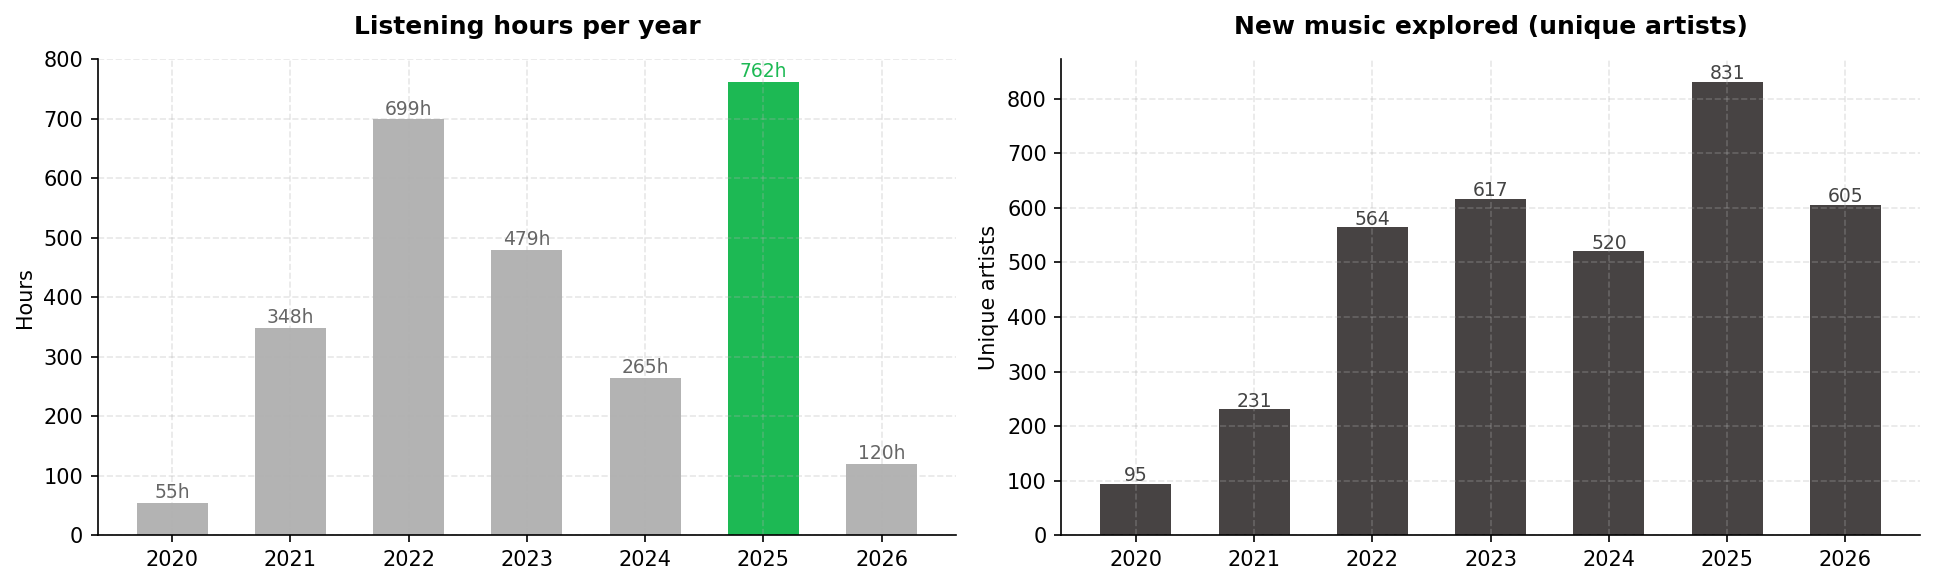

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hours per year
years = yearly.index.tolist()
hours = yearly["hours"].tolist()
colors = [PALETTE["primary"] if h == max(hours) else PALETTE["muted"] for h in hours]

axes[0].bar(years, hours, color=colors, width=0.6, edgecolor="none")
axes[0].set_title("Listening hours per year", fontweight="bold", pad=12)
axes[0].set_ylabel("Hours")
for i, (yr, h) in enumerate(zip(years, hours)):
    axes[0].text(yr, h + 8, f"{h:.0f}h", ha="center", fontsize=9,
                 color=PALETTE["primary"] if h == max(hours) else "#666")

# Unique artists per year
axes[1].bar(years, yearly["artists"], color=PALETTE["secondary"], width=0.6,
            alpha=0.8, edgecolor="none")
axes[1].set_title("New music explored (unique artists)", fontweight="bold", pad=12)
axes[1].set_ylabel("Unique artists")
for yr, a in zip(years, yearly["artists"]):
    axes[1].text(yr, a + 5, str(a), ha="center", fontsize=9, color="#444")

plt.tight_layout()
plt.savefig("../outputs/01_yearly_overview.png", bbox_inches="tight")
plt.show()


Monthly patterns: does listening follow a rhythm?

Aggregating by month reveals something that yearly totals obscure: listening isn't evenly distributed across the year. Some months are consistently heavy; others are quiet. The heatmap below shows hours per month for each year. Darker cells indicate more listening, read each row as a year, each column as a month.


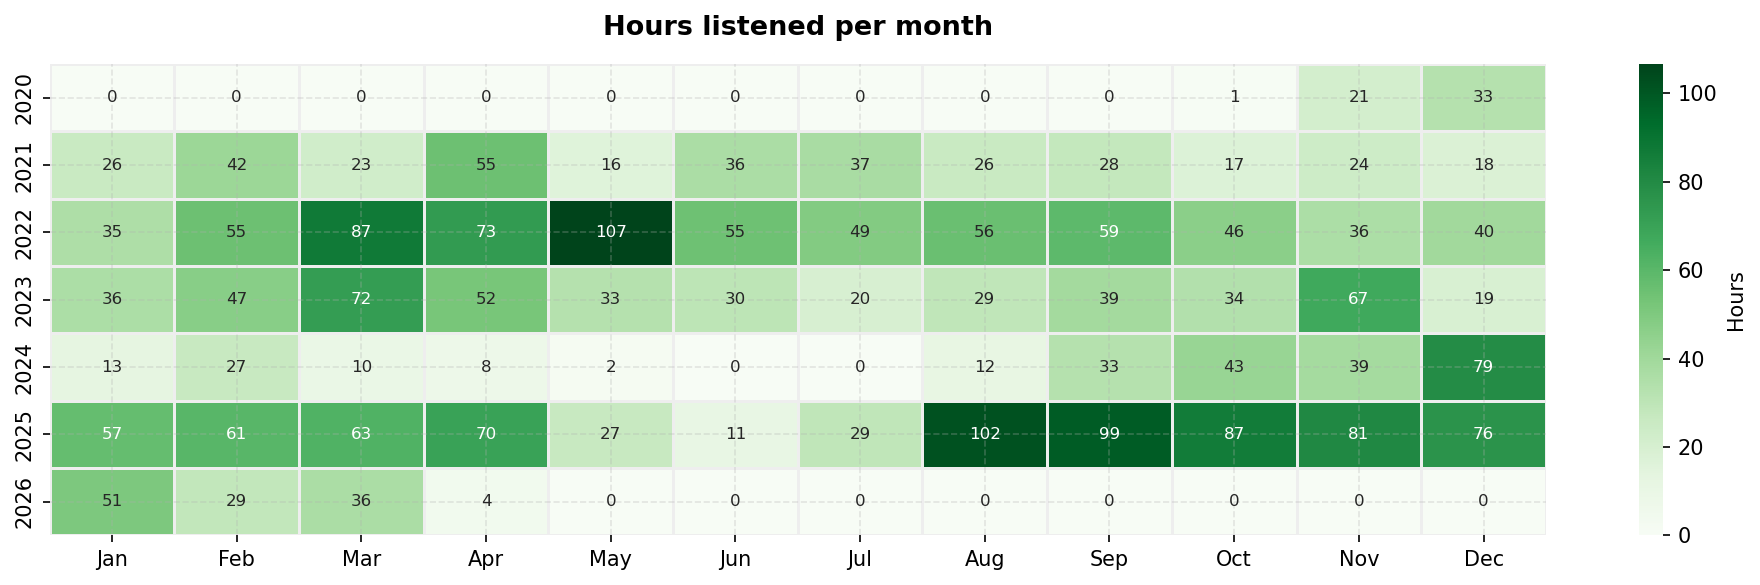

Notable: Aug 2025 = 102h — your single hottest month on record.


In [7]:
df_tracks["hours"] = df_tracks["ms_played"] / 3_600_000
monthly_pivot = (
    df_tracks.groupby(["year", "month"])["hours"]
    .sum()
    .unstack(fill_value=0)
)
monthly_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    monthly_pivot, ax=ax,
    cmap="Greens", linewidths=0.5, linecolor="#eee",
    annot=True, fmt=".0f", annot_kws={"size": 8},
    cbar_kws={"label": "Hours"},
)
ax.set_title("Hours listened per month", fontweight="bold", pad=14, fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../outputs/01_monthly_heatmap.png", bbox_inches="tight")
plt.show()
print("Notable: Aug 2025 = 102h — your single hottest month on record.")


Time of day: when does listening happen?

Streaming data carries an implicit behavioural signal: the hour of day. Whether someone listens primarily in the morning, during commutes, or late at night says something about the role music plays in their day. The heatmap below crosses hour of day with day of week — brighter cells indicate more plays at that hour on that day.


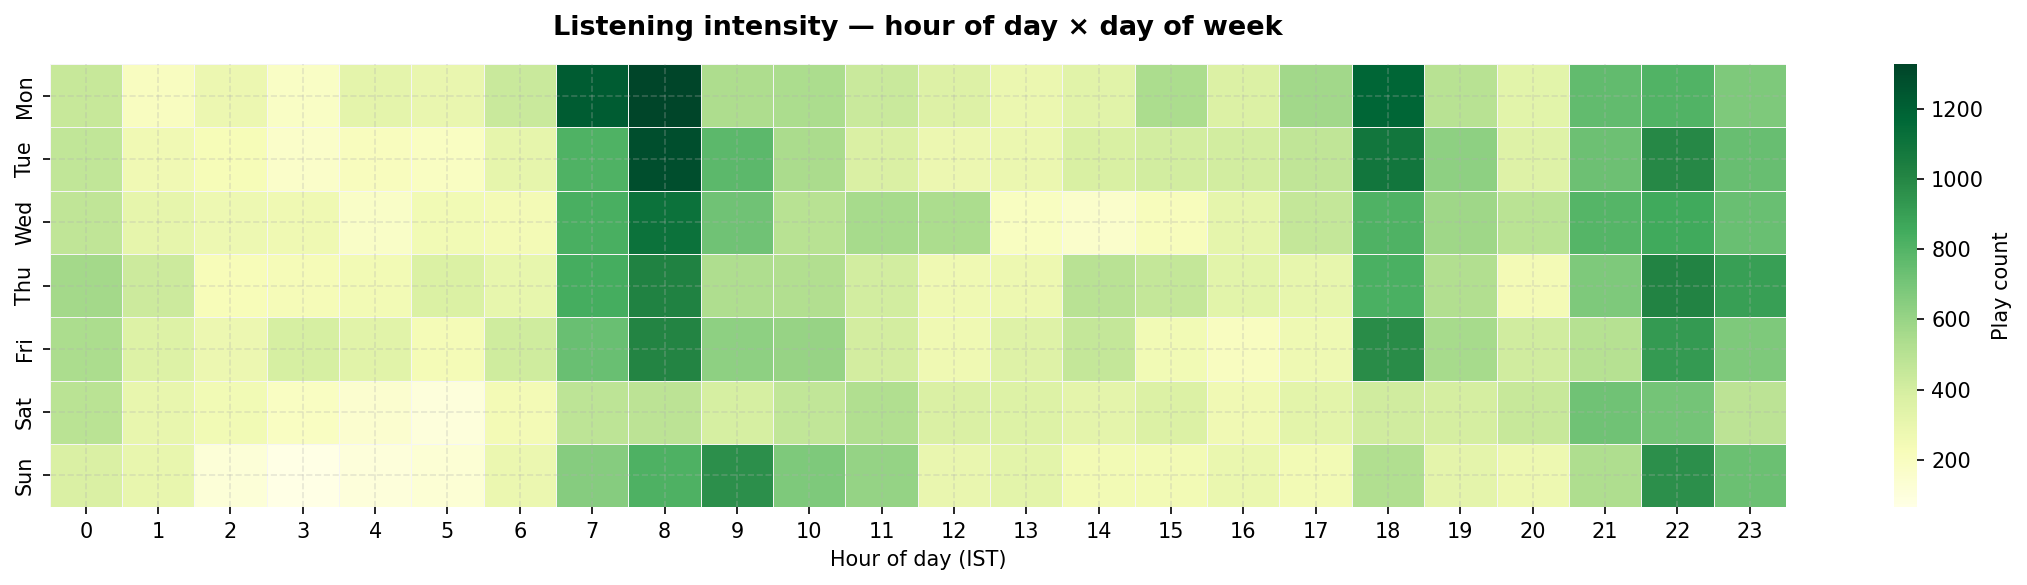

In [8]:
df_tracks["dow"] = df_tracks["ts_local"].dt.dayofweek
df_tracks["hour"] = df_tracks["ts_local"].dt.hour
heatmap_data = (
    df_tracks.groupby(["dow", "hour"])
    .size()
    .unstack(fill_value=0)
)
heatmap_data.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(
    heatmap_data, ax=ax,
    cmap="YlGn", linewidths=0.3, linecolor="#f5f5f5",
    cbar_kws={"label": "Play count"},
)
ax.set_title("Listening intensity — hour of day × day of week", 
             fontweight="bold", pad=14, fontsize=13)
ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../outputs/01_hourly_dow_heatmap.png", bbox_inches="tight")
plt.show()


In [1]:

hourly = df_tracks.groupby("hour").size().reset_index(name="plays")

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(hourly["hour"], hourly["plays"], 
                alpha=0.3, color=PALETTE["primary"])
ax.plot(hourly["hour"], hourly["plays"], 
        color=PALETTE["primary"], linewidth=2)


for h, label in [(8, "8am peak\n(morning commute)"),
                  (18, "6pm peak\n(evening wind-down)"),
                  (22, "10pm peak\n(late night)")]:
    val = hourly.loc[hourly["hour"] == h, "plays"].values[0]
    ax.annotate(label, xy=(h, val), xytext=(h, val + 300),
                ha="center", fontsize=8, color="#444",
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8))

ax.set_title("What time of day do you listen?", fontweight="bold", pad=12)
ax.set_xlabel("Hour of day (IST / local time)")
ax.set_ylabel("Total plays (all years)")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/01_hourly_curve.png", bbox_inches="tight")
plt.show()


NameError: name 'df_tracks' is not defined

---
## 6 · Artist distribution: concentration vs breadth

One question worth asking of any large listening dataset is whether it reflects broad exploration or deep concentration around a few favourites. The chart below answers this for the top 15 artists by total hours.


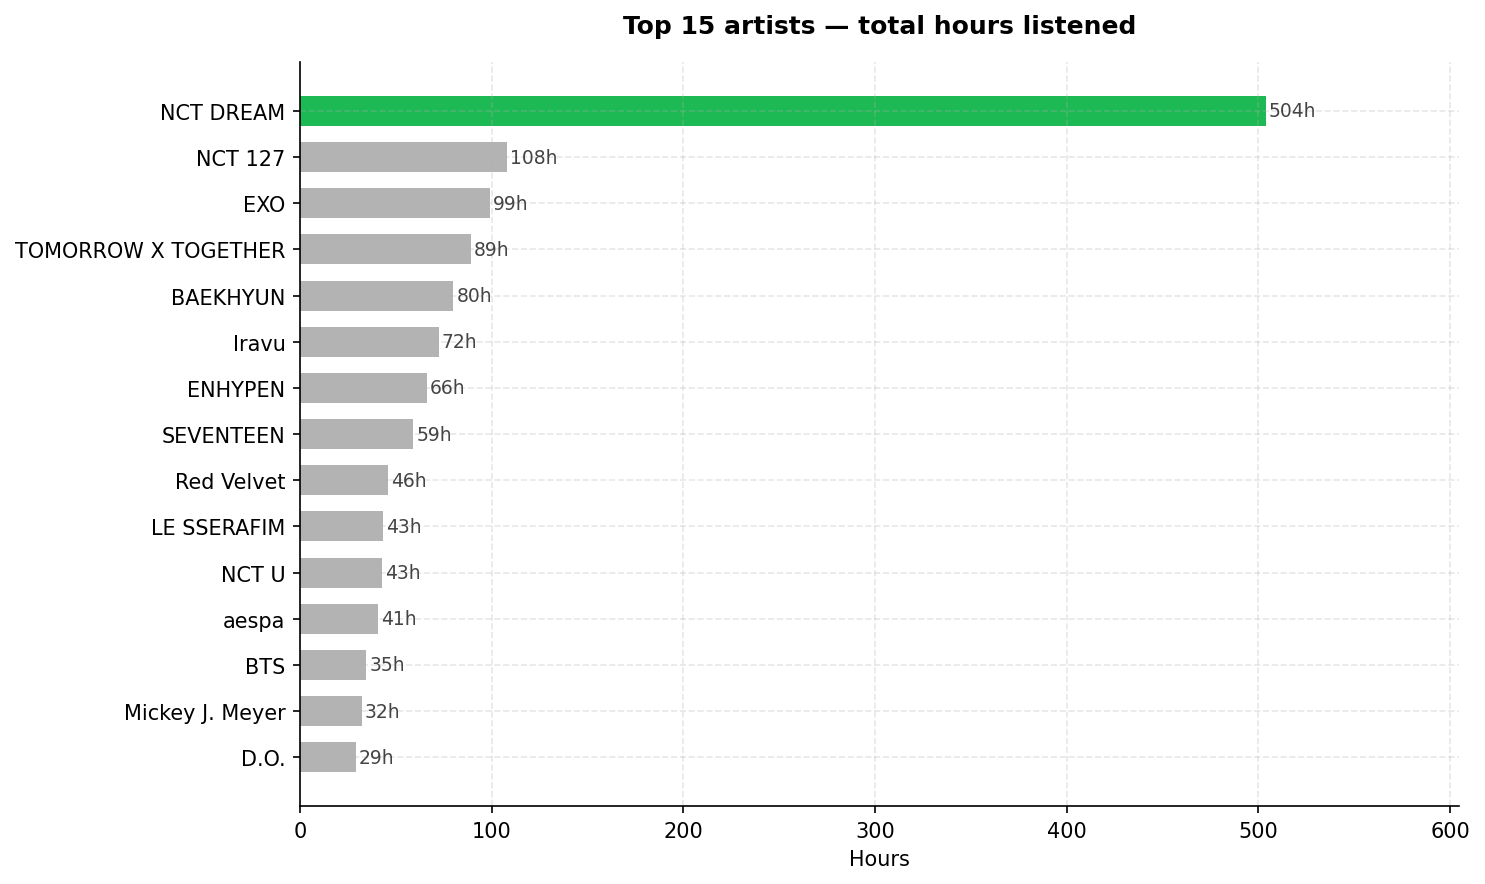

NCT DREAM = 504h = 18.5% of ALL listening time.


In [10]:
top_artists = (
    df_tracks.groupby("artist_name")["ms_played"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    / 3_600_000
).reset_index()
top_artists.columns = ["artist", "hours"]

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [PALETTE["primary"] if i == 0 else PALETTE["muted"] 
              for i in range(len(top_artists))]

bars = ax.barh(top_artists["artist"][::-1], top_artists["hours"][::-1],
               color=bar_colors[::-1], edgecolor="none", height=0.65)

for bar, h in zip(bars, top_artists["hours"][::-1]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f"{h:.0f}h", va="center", fontsize=9, color="#444")

ax.set_title("Top 15 artists — total hours listened", fontweight="bold", pad=14)
ax.set_xlabel("Hours")
ax.set_xlim(0, top_artists["hours"].max() * 1.2)
plt.tight_layout()
plt.savefig("../outputs/01_top_artists.png", bbox_inches="tight")
plt.show()

pct = top_artists.iloc[0]["hours"] / (df_tracks["ms_played"].sum()/3600000) * 100
print(f"NCT DREAM = {top_artists.iloc[0]['hours']:.0f}h = {pct:.1f}% of ALL listening time.")


---
## 7 · A closer look at the top artist

When a single artist accounts for nearly 15% of all plays across five years, that's not a passing phase — it's a structural feature of the dataset. Understanding the shape of that engagement (which tracks, which years, whether it's growing or fading) matters both for the story and for the feature engineering that follows.


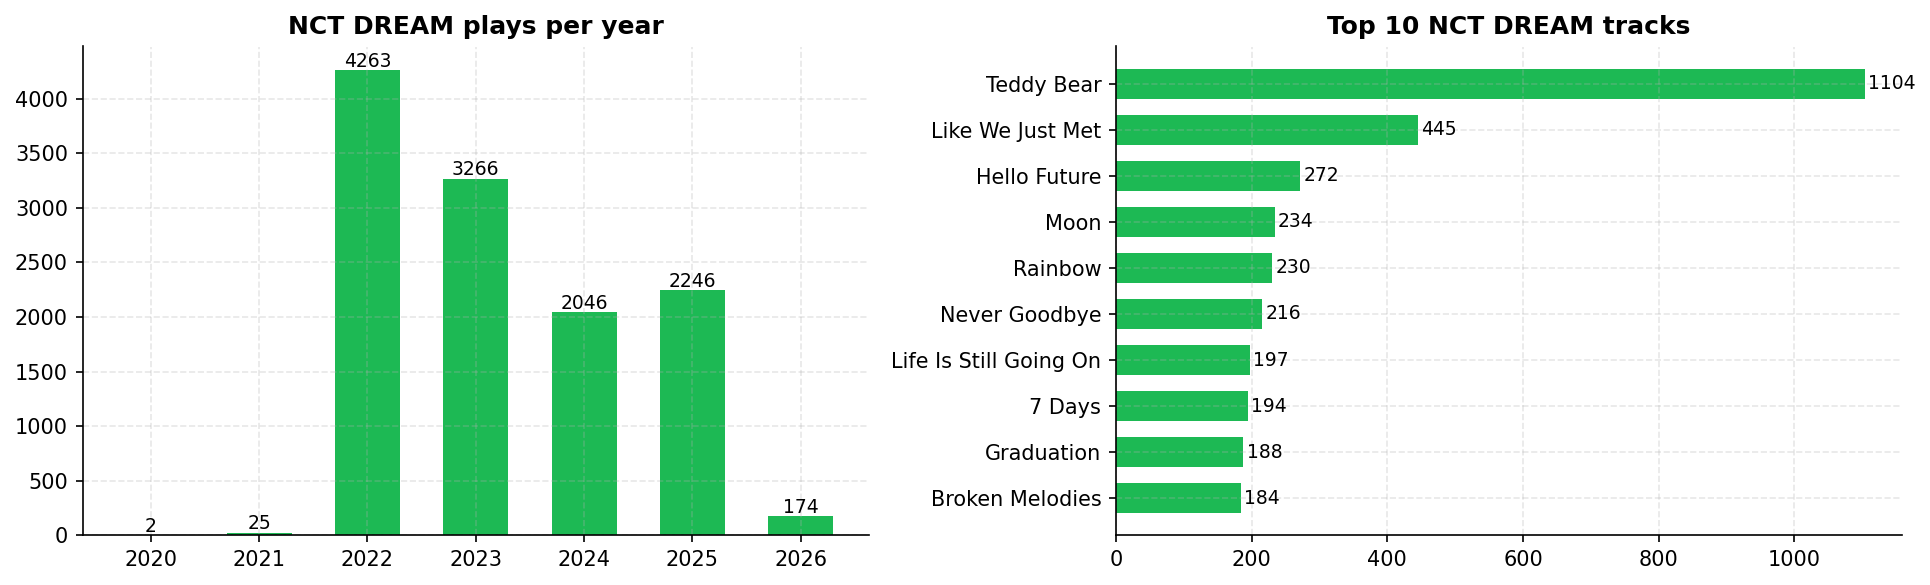

In [11]:
nct = df_tracks[df_tracks["artist_name"] == "NCT DREAM"].copy()
nct["year"] = nct["ts_local"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plays per year
nct_yearly = nct.groupby("year").size()
axes[0].bar(nct_yearly.index, nct_yearly.values, 
            color=PALETTE["primary"], width=0.6, edgecolor="none")
axes[0].set_title("NCT DREAM plays per year", fontweight="bold")
for yr, v in nct_yearly.items():
    axes[0].text(yr, v + 30, str(v), ha="center", fontsize=9)

# Top 10 NCT DREAM tracks
nct_tracks = nct["track_name"].value_counts().head(10)
axes[1].barh(nct_tracks.index[::-1], nct_tracks.values[::-1],
             color=PALETTE["primary"], edgecolor="none", height=0.65)
axes[1].set_title("Top 10 NCT DREAM tracks", fontweight="bold")
for i, v in enumerate(nct_tracks.values[::-1]):
    axes[1].text(v + 5, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/01_nct_dream.png", bbox_inches="tight")
plt.show()


---
## 8 · Replay behaviour: a case study

The most-played track in the dataset, *Teddy Bear* by NCT DREAM, has 1,112 plays. That's a meaningful signal for the recommender model: a track played over four consecutive years, across two countries, isn't a novelty, it's something the listener consistently returns to. The chart below shows its monthly play count from first listen to last.


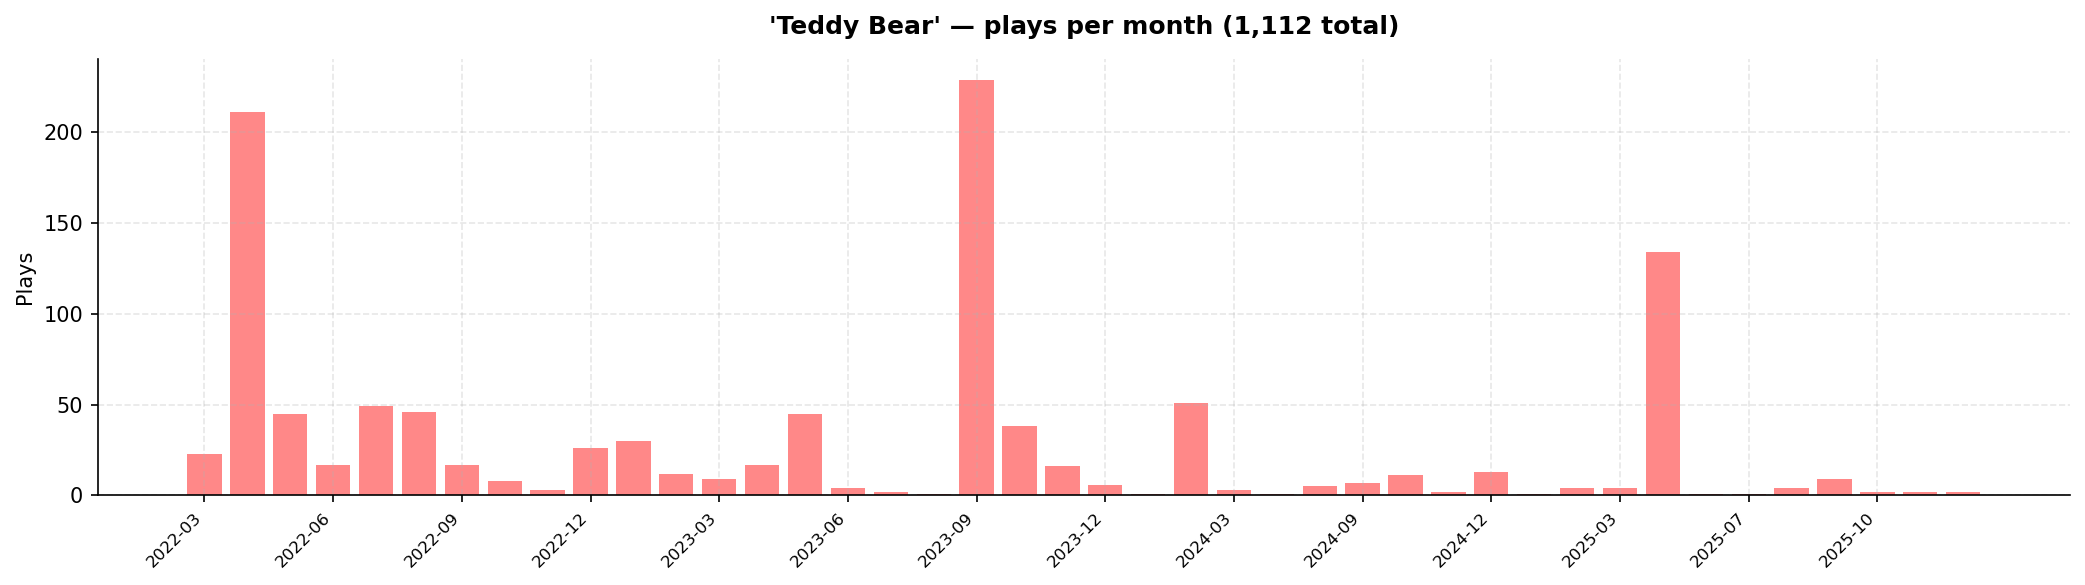

First play: 28 Mar 2022
Last play:  27 Jan 2026
That's 1401 days of loving this song.


In [12]:
teddy = df_tracks[df_tracks["track_name"] == "Teddy Bear"].copy()
teddy["year_month"] = teddy["ts_local"].dt.to_period("M")

monthly_teddy = teddy.groupby("year_month").size()
x_labels = [str(p) for p in monthly_teddy.index]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(monthly_teddy)), monthly_teddy.values,
       color=PALETTE["accent"], alpha=0.8, edgecolor="none", width=0.8)
ax.set_title("'Teddy Bear' — plays per month (1,112 total)", 
             fontweight="bold", pad=12)
ax.set_ylabel("Plays")
ax.set_xticks(range(0, len(x_labels), 3))
ax.set_xticklabels(x_labels[::3], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/01_teddy_bear.png", bbox_inches="tight")
plt.show()
print(f"First play: {teddy['ts_local'].min().strftime('%d %b %Y')}")
print(f"Last play:  {teddy['ts_local'].max().strftime('%d %b %Y')}")
print(f"That's {(teddy['ts_local'].max() - teddy['ts_local'].min()).days} days of loving this song.")


---
## 9 · Geographic context: where the listening happened

The dataset contains a `conn_country` field that records which country the listener was in at the time of each play. This isn't metadata about the music, it's context about the listener. The distribution below shows a clear structural shift mid-dataset that is worth understanding before building any time-aware models.


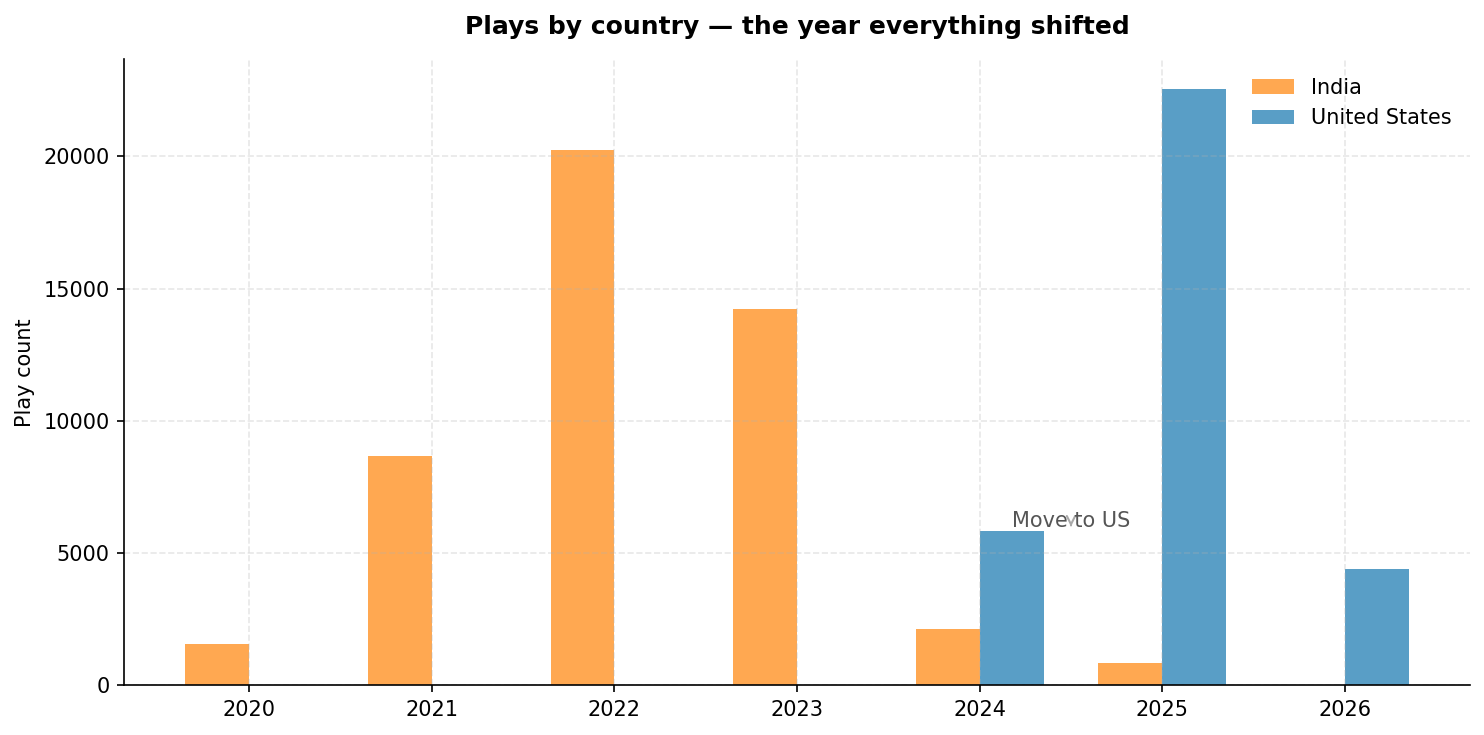

In [13]:
country_year = (
    df_tracks.groupby(["year", "conn_country"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"IN": "India", "US": "United States", "GB": "United Kingdom"})
)

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(len(country_year.index))

india_bars = ax.bar(x - width/2, country_year.get("India", 0),
                    width, label="India", color=PALETTE["india"],
                    alpha=0.85, edgecolor="none")
us_bars = ax.bar(x + width/2, country_year.get("United States", 0),
                 width, label="United States", color=PALETTE["us"],
                 alpha=0.85, edgecolor="none")

ax.set_title("Plays by country — the year everything shifted", 
             fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(country_year.index)
ax.set_ylabel("Play count")
ax.legend(frameon=False)

# Annotate the crossover
ax.annotate("Move to US", xy=(4.5, 6000), fontsize=10,
            color="#555", ha="center",
            arrowprops=dict(arrowstyle="->", color="#aaa"))

plt.tight_layout()
plt.savefig("../outputs/01_india_vs_us.png", bbox_inches="tight")
plt.show()


---
## 10 · Skip behaviour: how engagement changed over time

The `skipped` field is one of the most analytically useful columns in the dataset. A skip is an explicit signal: the listener heard enough and decided to move on. The chart below shows skip rate by year, but the early years require a caveat.


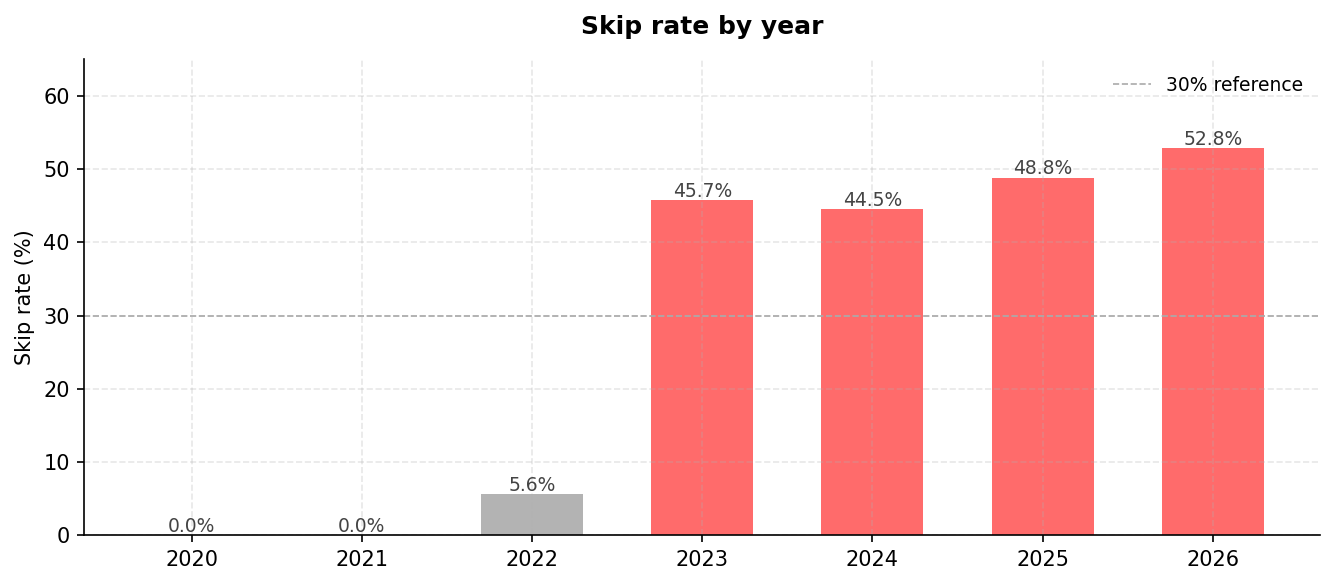

Note: 2020 and 2021 show 0% because Spotify's extended history
did not record skip data for those years — not because you never skipped.


In [14]:
skip_by_year = (df_tracks.groupby("year")["skipped"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(skip_by_year.index, skip_by_year.values,
              color=[PALETTE["accent"] if v > 40 else PALETTE["muted"] 
                     for v in skip_by_year.values],
              width=0.6, edgecolor="none")
for yr, v in skip_by_year.items():
    ax.text(yr, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9, color="#444")

ax.set_title("Skip rate by year", fontweight="bold", pad=12)
ax.set_ylabel("Skip rate (%)")
ax.set_ylim(0, 65)
ax.axhline(y=30, color="#aaa", linestyle="--", linewidth=0.8, label="30% reference")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/01_skip_rate.png", bbox_inches="tight")
plt.show()

print("Note: 2020 and 2021 show 0% because Spotify's extended history")
print("did not record skip data for those years — not because you never skipped.")


---
## 11 · Late-night listening

Plays between midnight and 5am are a small fraction of the total, but their growth over time is striking. Whether this reflects a shift in lifestyle, timezone changes, or simply longer listening sessions that extend into the night is worth examining — and it's the kind of pattern that makes a time-of-day feature genuinely interesting for modelling.


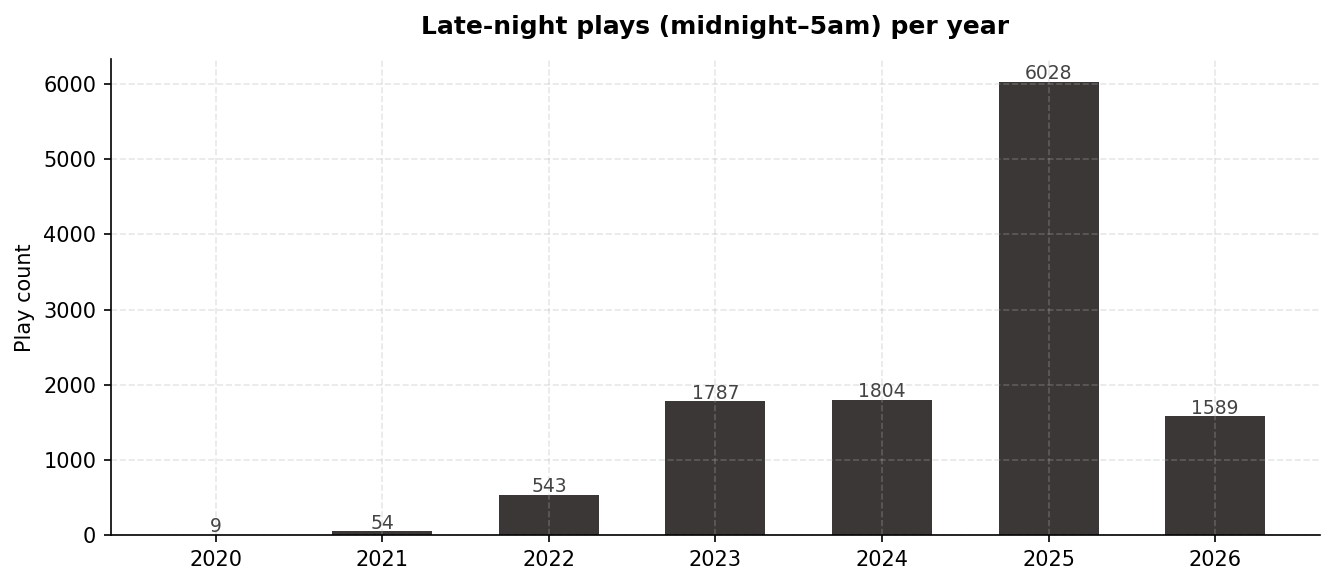

In [15]:
late_night = df_tracks[df_tracks["hour"].between(0, 5)]
late_by_year = late_night.groupby("year").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(late_by_year.index, late_by_year.values,
       color=PALETTE["secondary"], alpha=0.85, width=0.6, edgecolor="none")
for yr, v in late_by_year.items():
    ax.text(yr, v + 30, str(v), ha="center", fontsize=9, color="#444")
ax.set_title("Late-night plays (midnight–5am) per year", fontweight="bold", pad=12)
ax.set_ylabel("Play count")
plt.tight_layout()
plt.savefig("../outputs/01_late_night.png", bbox_inches="tight")
plt.show()


---
## 12 · What this analysis surfaces

EDA is most useful when it produces concrete questions for the next stage. Here is what this pass through the data suggests.

| Observation | What it implies |
|---|---|
| NCT DREAM: 14.9% of all plays | Artist identity is highly concentrated — clustering will likely find a dominant K-pop persona |
| Skip rate: 0% (2020–21) → 52% (2026) | Pre-2022 data should be excluded from any skip-based model; the field was not recorded |
| Three daily peaks: 8am, 6pm, 10pm | Hour of day is a strong candidate feature for mood and context prediction |
| Geographic shift in 2024 | Country is not a stable background variable — treat it as a time-varying contextual feature |
| Teddy Bear: 1,112 plays over 4 years | Ultra-high replay rate is a reliable positive signal for the recommender |
| 1,750 unique artists, 7,039 tracks | Sufficient diversity for collaborative filtering to find meaningful structure |
| Late-night plays grew 100× from 2021 to 2025 | Time-of-day patterns shifted; models trained on early years may not generalise |

### What comes next

- **Notebook 02** — deeper analysis: genre and mood patterns, decade fingerprint, listening streaks
- **Notebook 03** — machine learning: listener persona clustering, mood classifier, skip predictor
- **Notebook 04** — recommender system: cosine similarity and matrix factorisation
